# Retention Strategy Framework

This notebook translates the customer analytics developed in previous notebooks into a practical retention strategy framework.

The project uses two separate datasets:

1. **Online Retail** — RFM analysis, behavioral segmentation, and customer lifetime value (CLTV).
2. **Telco Customer Churn** — supervised churn prediction and churn-risk analysis.

These datasets represent different business contexts and are **not merged**. Instead, their outputs are used to demonstrate how customer value, engagement, and churn risk can support retention decision-making.

## Objectives

This notebook will:

- Summarize customer value segments from the Online Retail analysis.
- Summarize churn-risk findings from the Telco analysis.
- Connect customer value with retention priorities conceptually.
- Define actionable retention strategies for different customer profiles.
- Identify limitations and assumptions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
rfm = pd.read_csv(
    "../data/processed/customer_segmentation.csv"
)

cltv = pd.read_csv(
    "../data/processed/customer_cltv.csv"
)

print("RFM dataset shape:", rfm.shape)
print("CLTV dataset shape:", cltv.shape)

RFM dataset shape: (4338, 19)
CLTV dataset shape: (4338, 28)


In [3]:
telco = pd.read_csv(
    "../data/processed/telco_churn_clean.csv"
)

print("Telco dataset shape:", telco.shape)

Telco dataset shape: (7043, 22)


## 1. Customer Value Segmentation

The Online Retail analysis identified four behavioral customer segments using RFM-related and engagement features.

The segments describe customers based on historical purchasing behavior, rather than predicted future behavior.

In [4]:
segment_summary = (
    cltv
    .groupby("BehavioralSegment")
    .agg(
        Customers=("CustomerID", "count"),
        MeanCLTV=("CLTV", "mean"),
        MedianCLTV=("CLTV", "median"),
        TotalCLTV=("CLTV", "sum")
    )
    .sort_values("TotalCLTV", ascending=False)
)

segment_summary

,Customers,MeanCLTV,MedianCLTV,TotalCLTV
BehavioralSegment,,,,
At-Risk Valuable Customers,1340,"7,587.88","4,648.50","10,167,755.20"
Engaged Loyal Customers,1418,"5,976.50","4,304.48","8,474,683.81"
High-Value Champions,465,"15,118.89","7,914.86","7,030,284.98"
Low-Value Inactive Customers,1115,"1,872.73","1,762.20","2,088,090.21"


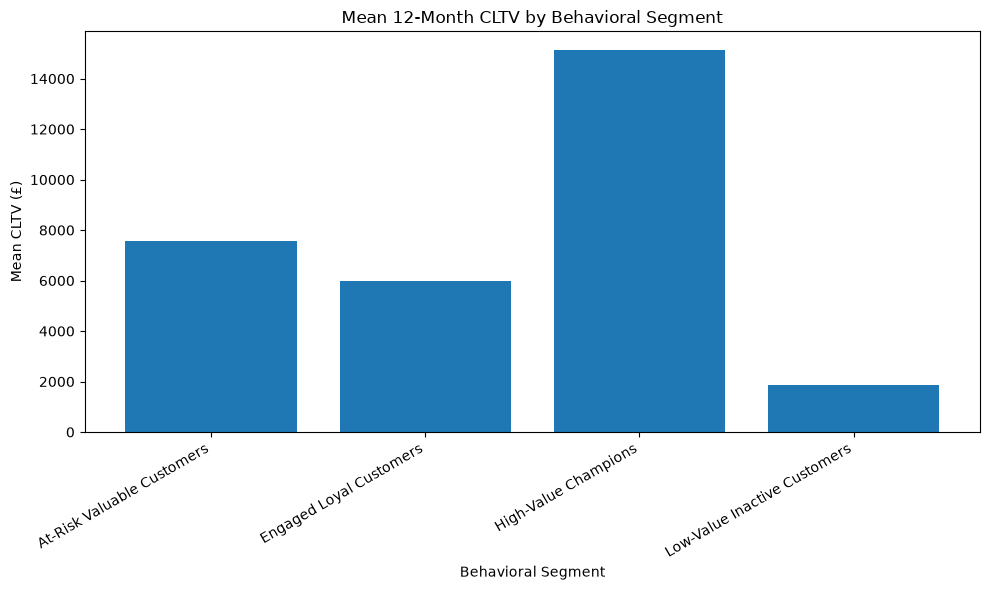

In [5]:
plt.figure(figsize=(10, 6))

plt.bar(
    segment_summary.index,
    segment_summary["MeanCLTV"]
)

plt.title("Mean 12-Month CLTV by Behavioral Segment")
plt.xlabel("Behavioral Segment")
plt.ylabel("Mean CLTV (£)")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

## 2. Churn Risk Profile

The Telco analysis provides a supervised churn-risk perspective.

The model predicts the probability that a customer will churn. Because the Online Retail and Telco datasets represent different business contexts, these churn probabilities are not assigned to the Online Retail segments.

Instead, the churn model demonstrates how behavioral and contractual customer attributes can be used to identify customers requiring retention attention.

In [6]:
churn_summary = (
    telco["Churn"]
    .value_counts()
    .rename_axis("Churn")
    .reset_index(name="Customers")
)

churn_summary["Percentage"] = (
    churn_summary["Customers"]
    / churn_summary["Customers"].sum()
    * 100
)

churn_summary

,Churn,Customers,Percentage
0,No,5174,73.46
1,Yes,1869,26.54


In [7]:
contract_churn = (
    telco
    .groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
    .sort_values("ChurnRate", ascending=False)
)

contract_churn

,Contract,ChurnRate
0,Month-to-month,42.71
1,One year,11.27
2,Two year,2.83


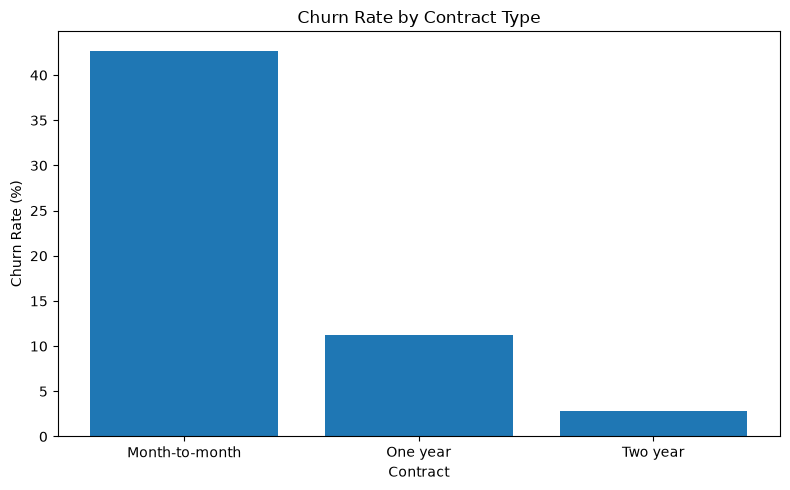

In [8]:
plt.figure(figsize=(8, 5))

plt.bar(
    contract_churn["Contract"],
    contract_churn["ChurnRate"]
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

## 3. Retention Strategy Framework

A practical retention program should consider both customer value and customer risk.

The following framework is conceptual rather than a direct mapping between the two datasets. It illustrates how organizations can prioritize different interventions based on combinations of customer value, engagement, and churn risk.

In [9]:
retention_strategy = pd.DataFrame({
    "Customer Profile": [
        "High value + high churn risk",
        "High value + low churn risk",
        "Medium value + high churn risk",
        "Low value + high churn risk",
        "Low value + low churn risk"
    ],
    "Retention Objective": [
        "Prevent high-value customer loss",
        "Protect and deepen loyalty",
        "Reduce avoidable churn",
        "Retain selectively based on economics",
        "Use low-cost engagement"
    ],
    "Potential Actions": [
        "Personalized outreach, service recovery, targeted incentives",
        "Loyalty rewards, cross-sell, premium experiences",
        "Onboarding improvement, targeted offers, support outreach",
        "Automated campaigns and low-cost offers",
        "Automated engagement and product recommendations"
    ]
})

retention_strategy

,Customer Profile,Retention Objective,Potential Actions
0,High value + high churn risk,Prevent high-value customer loss,"Personalized outreach, service recovery, targe..."
1,High value + low churn risk,Protect and deepen loyalty,"Loyalty rewards, cross-sell, premium experiences"
2,Medium value + high churn risk,Reduce avoidable churn,"Onboarding improvement, targeted offers, suppo..."
3,Low value + high churn risk,Retain selectively based on economics,Automated campaigns and low-cost offers
4,Low value + low churn risk,Use low-cost engagement,Automated engagement and product recommendations


## 4. Retention Prioritization

Retention resources are usually limited, so customer value and churn risk should be considered together.

The following framework prioritizes intervention intensity conceptually:

- High-value customers with elevated churn risk → proactive human intervention
- High-value customers with low churn risk → loyalty and expansion
- Medium-value customers with elevated churn risk → targeted automated or assisted retention
- Low-value customers with elevated churn risk → low-cost automated retention
- Low-risk customers → relationship-building and cross-selling

This framework does not claim that a particular intervention will cause a specific change in churn probability. Actual campaign effectiveness should be measured through controlled experiments.

In [10]:
priority_framework = pd.DataFrame({
    "Priority": [
        "Critical",
        "High",
        "Medium",
        "Low"
    ],
    "Customer Situation": [
        "High value + high churn risk",
        "High value + moderate churn risk",
        "Medium value + high churn risk",
        "Low value or low-risk customers"
    ],
    "Recommended Approach": [
        "Personalized retention intervention",
        "Targeted loyalty and proactive engagement",
        "Segmented offers and service outreach",
        "Automated, low-cost engagement"
    ],
    "Measurement": [
        "Retention rate, revenue retained, intervention ROI",
        "Repeat purchase, expansion, retention",
        "Churn reduction, offer response rate",
        "Engagement rate and campaign cost"
    ]
})

priority_framework

,Priority,Customer Situation,Recommended Approach,Measurement
0,Critical,High value + high churn risk,Personalized retention intervention,"Retention rate, revenue retained, intervention..."
1,High,High value + moderate churn risk,Targeted loyalty and proactive engagement,"Repeat purchase, expansion, retention"
2,Medium,Medium value + high churn risk,Segmented offers and service outreach,"Churn reduction, offer response rate"
3,Low,Low value or low-risk customers,"Automated, low-cost engagement",Engagement rate and campaign cost


## 5. Business Recommendations

### 1. Protect valuable customers

The Online Retail analysis identified **At-Risk Valuable Customers** as a substantial customer group with high modeled aggregate CLTV. These customers can represent an important retention opportunity because their historical purchasing value is relatively high while their recent activity is weaker.

Potential actions include:

- Personalized re-engagement
- Product recommendations based on previous purchases
- Targeted incentives
- Service recovery for customers with negative experiences

### 2. Protect high-value champions

High-Value Champions have the highest average modeled CLTV in the segmentation analysis.

Potential actions include:

- Loyalty rewards
- Early access to products
- Personalized recommendations
- Cross-selling and upselling
- Premium customer experiences

### 3. Address early churn risk

The Telco analysis showed substantially different descriptive churn rates across contract types. Month-to-month customers had a higher observed churn rate than one-year and two-year contract customers.

Potential actions include:

- Improve onboarding during the early customer lifecycle
- Identify customers showing early disengagement
- Offer appropriate longer-term plans where commercially suitable
- Provide proactive service and support

These actions should be evaluated experimentally rather than treated as guaranteed causes of lower churn.

### 4. Use model-based prioritization

The XGBoost churn model can provide a probability-based screening mechanism.

For example, the project used a **0.20 threshold** for a high-recall screening scenario. Under the illustrative cost assumptions used in Notebook 05, this threshold minimized the tested cost function.

The threshold should be recalibrated using real business costs before production deployment.

### 5. Measure retention economics

Future retention campaigns should track:

- Customers contacted
- Customers retained
- Revenue retained
- Cost of intervention
- Offer redemption
- Incremental revenue
- Customer lifetime value
- Churn rate
- Return on retention investment

A/B testing or controlled experiments should be used where feasible to estimate the incremental effect of retention interventions.

## 6. Limitations

Several limitations should be considered:

1. **The datasets represent different businesses and customers.** They were intentionally not merged.

2. **The Online Retail CLTV is a scenario-based revenue proxy.** It does not represent statistically estimated future profit and does not explicitly model margins, discounting, or customer survival probabilities.

3. **RFM and behavioral segments are descriptive.** Segment membership does not establish why a customer behaves in a particular way.

4. **Churn model performance depends on the historical Telco dataset.** Performance on another population or future data may differ.

5. **The churn threshold is business-dependent.** The 0.20 threshold was selected for a particular illustrative cost scenario and should not be treated as universally optimal.

6. **SHAP explains model behavior rather than causality.** A feature with high SHAP importance should not automatically be interpreted as a causal driver of churn.

7. **Retention actions require experimentation.** Observational analysis cannot establish that a particular campaign will reduce churn.

## 7. Conclusion

This project combines customer segmentation, customer lifetime value estimation, and churn prediction into a practical retention analytics framework.

The Online Retail analysis demonstrated how RFM and behavioral features can identify distinct customer groups and estimate their potential revenue value. The Telco analysis demonstrated how machine learning can estimate churn risk from customer characteristics and how prediction thresholds can be adjusted according to business costs.

Together, these components provide a foundation for a retention decision system:

**Customer behavior → Customer value → Churn risk → Retention priority → Targeted action → Business measurement**

The next stage would be to operationalize these analyses through a dashboard or API so that customer information can be evaluated interactively and retention decisions can be monitored over time.